<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:50px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Nonuniform sensitivity
  </span>
</h1>

In [13]:
import numpy as np
import os 

%matplotlib inline 
from matplotlib import pyplot as plt
from photutils.aperture import EllipticalAperture

from convenience_functions import show_image
import image_sim as isim #auxiliary library containing all the functions for generating realistic CCD simulations.

# Background

Not all pixels in a camera have the same sensitivity to light: there are intrinsic differences from pixel-to-pixel. Vignetting, a dimming near the corners of an image caused by the optical system to which the camera is attached, and dust on optical elements such as filters, the glass window covering the CCD, and the CCD chip itself can also block some light.<br>
Vignetting and dust can reduce the amount of light reaching the CCD chip while pixel-to-pixel sensitivity variations affects the counts read from the chip. (dust blocks some of the light, creating shadows (those "donuts" you see in the example image)).

---
# A sample Flat Image

The “donuts” in the image are dust on elements like filters in the optical path. Note that the size of the variations is small, a few percent at most.

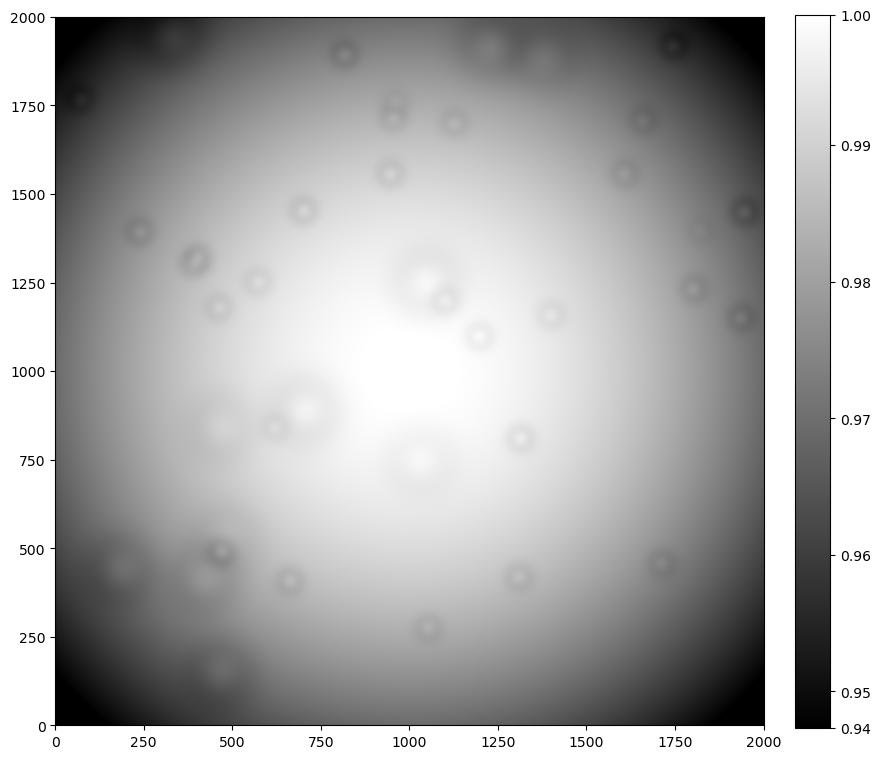

In [21]:
image = np.zeros([2000, 2000])
flat = isim.sensitivity_variations(image)

show_image(flat, cmap='gray')

# Effect of nonuniform sensitivity on images

How does this affect the final image? (Sensor "errors" that add up, independent of the amount of light that arrives.)
<br> $image = bias + noise + dark current + sky + stars$ 

<br>

(flat) sensibility map, it only multiplies the portion of light that comes from the sky and the stars **x** the light that really matters (sky + stars)

$image = bias + noise + darkcurrent + flat(sky + stars)$

---

# A realistic image

An image showing EVERYTHING that has been worked on so far. Its a simulation of what a real CCD camera will would capture when photographing the sky, with ALL effects that happen in real life. 

Add model sources:   0%|          | 0/50 [00:00<?, ?it/s]

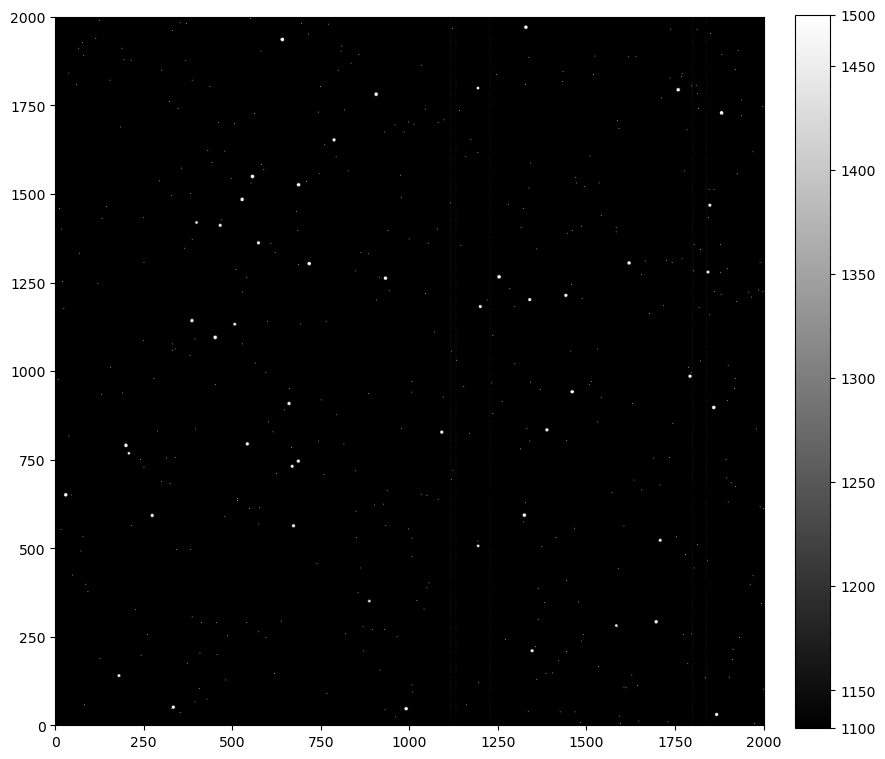

In [23]:
gain = 1.0
exposure = 30.0
dark = 0.1
sky_counts = 20
bias_level = 1100
read_noise_electrons = 5
max_stars_counts = 2000

bias_only = isim.bias(image, bias_level, realistic=True)
noise_only = isim.read_noise(image, read_noise_electrons, gain=gain)
dark_only = isim.dark_current(image, dark, exposure, gain=gain, hot_pixels=True)
sky_only = isim.sky_background(image, sky_counts, gain=gain)
stars_only = isim.stars(image, 50, max_counts=max_stars_counts)

final_image = bias_only + noise_only + dark_only + flat * (sky_only + stars_only)

show_image(final_image, cmap='gray', percu = 99.9)

Visually, this does not look any different than the final image in the previous notebook; the effects of sensitivity variations are typically not evident in raw images unless the sky background is large.

You can see the effect by artificially increasing the sky background.

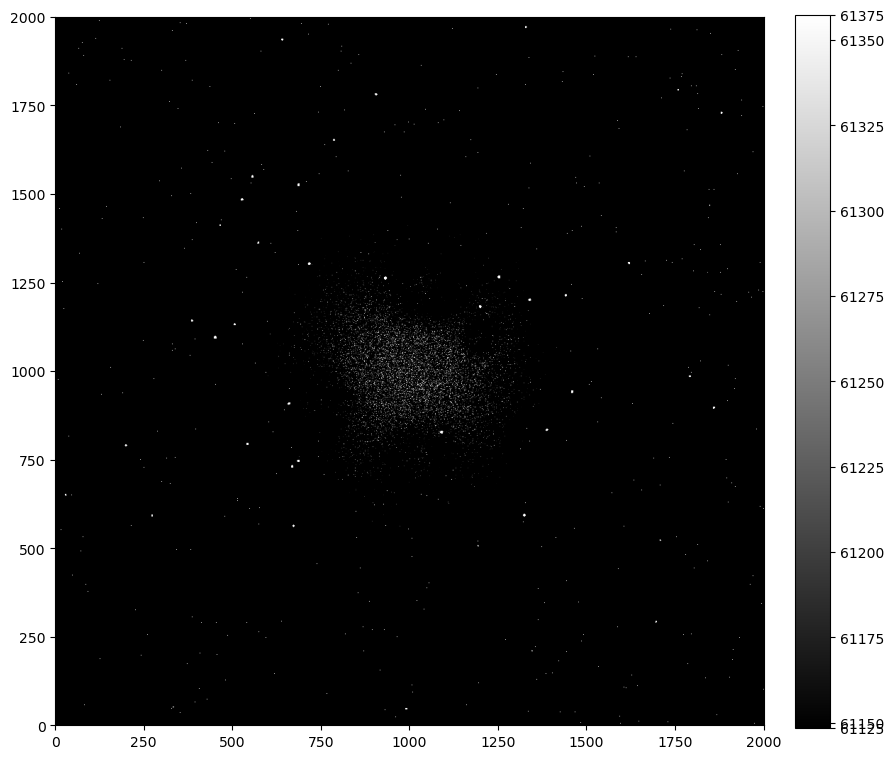

In [25]:
#forçar o céu a ficar mais brilhante, pro efeito do flat ficar mais visível
# céu 3000 + brilhante = 60000 counts

final_image2 = bias_only + noise_only + dark_only + flat * (isim.sky_background(image, 3000 * sky_counts, gain=gain) + stars_only)
show_image(final_image2, cmap='gray', percu = 99.9)

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Notes
  </span>
</h1>

**LEMBRAR** que:

- bias é necessário !! subtrai pra tirar
- noise é indesejado (NÃO dá pra tirar)
- dark é indesejado (dark current dá pra tirar subtraindo, precisa do dark frames)
- flat é corrigível (dá pra tirar dividindo)
- sky é neutro né..
- stars é o que queria !
  
- flat é como um "mapa de imperfeições" precisa para corrigir as fotos astronômicas reais, mapa de sensibilidade dos pixels
- donuts é aquela poeira que cria imagem tipo donuts, anéis
- vignetting são os cantos mais escuros que o centro (efeito de foto que existe por ai tbm)
- sky_counts * 3000 (qualquer outro número) = truque pra fazer aparecer o flat

---

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Links
  </span>
</h1>

https://github.com/astropy/ccd-reduction-and-photometry-guide<br>https://github.com/nyny2903/astropy-coisas/tree/main/Astropy_tutorials<br>https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-04-Nonuniform-sensitivity.html